# 5. Analysis of g-mode pulsators

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [5]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
from scipy.stats import binned_statistic
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.ndimage import median_filter
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim extra
import natsort
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.mocka      as mk
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [15]:
# Define paths used throughout
path = '/lhome/nicholas/software/workdir/mocka/simulations/mocka'
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
vdir = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/data_varsim'
cmap = 'rainbow'

---
## Test to compare input and output
---

### Quicklook for $\gamma$ Dor and SPB star analysis

In [14]:
star = 'SPB'
pathx = f'{path}/{star}/clean'
patha = f'{path}/{star}/affogato'
pathc = f'{path}/{star}/cortado'
pathd = f'{path}/{star}/doppio'
pathv = f'{path}/{star}/varsource'

In [ ]:
# Choose simulation
idir = patha
starID = f'{3}'.zfill(9)

# Fetch final ligth curve
lc = LightCurve(f'{idir}/lightcurve/lc_{starID}.ftr', mode="final")
df = lc.data()

# Load sim table
dt = pd.read_feather(f'{idir}/table/table_{starID}.ftr')

# Create varsource from pulsations
dx = pd.read_feather(f'{pathv}/pulsations/pulsations_{starID}_001.ftr')
dv = pd.DataFrame()
dv['time'] = df.time / 86400
dv['dmag'] = ns.timeSeriesFromFourier(dv.time, dx.freq, dx.ampl, dx.phase, power=2.2)
dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e6

#------------------

# Load star results
dm = pd.read_feather(f'{patha}/modes/modes_{starID}.ftr')
dp = pd.read_feather(f'{pathv}/parameters/parameters_{starID}_001.ftr')
df = pd.read_feather(f'{pathv}/pulsations/pulsations_{starID}_001.ftr')

# Correct for gamma factor
df.ampl /= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)
# print(dex_df)
# print(dex_dm)

# O-C plot
f_oc = df0.freq.to_numpy() - dm0.freq.to_numpy()
A_oc = df0.ampl.to_numpy() - dm0.ampl.to_numpy()
dm1 = dm[dm.passed_snr]

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
# x = 0.005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Dominant amplitude : {df.ampl.max():.4f} ppm')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

#--------------------------------------------------------------------------------------------

# EXAMPLE PLOT OF MODE EXTRACTION
fig, ax = plt.subplots(5, 1, figsize=(9,10))

# Full range
xmin = np.min([df0.freq.min(), dm.freq.min()])
xmax = np.max([df0.freq.max(), dm.freq.max()])
xlim0 = pt.getAxesMinMax(x=[xmin, xmax], percentage=3)

# Zoom-in one systematics
dm_sys = dm.loc[:2] #[~(dm.freq == dm0.freq)]
xlim1 = (0, 0.45)
ylim1 = pt.getAxesMinMax(y=dm_sys.ampl.to_numpy(), percentage=100)

# Zoom-in on mode pattern
xlim2 = pt.getAxesMinMax(x=df.freq.to_numpy(), percentage=5)[::-1]
ylim2 = pt.getAxesMinMax(x=df.ampl.to_numpy(), percentage=5)

# Plot all modes detected
ax[0].axvspan(0,        xlim1[1], color='b', alpha=0.1, lw=0, label='Zoom-in noise')
ax[0].axvspan(xlim2[0], xlim2[1], color='g', alpha=0.1, lw=0, label='Zoom-in pattern')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1]+1, ls=':', c='k', label='Detection limit') 
ax[0].plot(df0.freq, df0.ampl, 'o', ms=5, c='orange', mec='k', label='Pattern input')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, 
               mec='lightgray', color="orangered",  label='Detected BIC')
ax[0].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=8, 
               mec='lightgray', color="green", label='Detected SNR')
handles, labels = ax[0].get_legend_handles_labels()
order = [0,1,2,3,4,5]
ax[0].legend([handles[i] for i in order], [labels[i] for i in order], 
             loc='upper center', ncol=3, bbox_to_anchor=(0.46, 1.66), fontsize=15.2)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

# Zoom-in on noise
ax[1].axvspan(xlim1[0], xlim1[1], color='b', alpha=0.05, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k')
ax[1].axvline(x=1/(1*(ut.quarter()-1)), ls='--', c='royalblue', label=r'$1 \times t_{\rm Q}$')
ax[1].axvline(x=1/(2*(ut.quarter()-1)), ls='-.', c='royalblue', label=r'$2 \times t_{\rm Q}$')
ax[1].axvline(x=1/(3*(ut.quarter()-1)), ls=':',  c='royalblue', label=r'$3 \times t_{\rm Q}$')
ax[1].axvline(x=1/(4*(ut.quarter()-1)), ls='--',  c='c')#, label=r'$1 \times t_{\rm Q}$')
ax[1].axvline(x=1/(6*(ut.quarter()-1)), ls='-.',  c='c')#, label=r'$1 \times t_{\rm Q}$')
ax[1].axvline(x=1/(8*(ut.quarter()-1)), ls=':',  c='c')#, label=r'$1 \times t_{\rm Q}$')
ax[1].axvline(x=1/3,                    ls='--', c='orange',    label=r'$t_{\rm wheel-off}$')
ax[1].axvline(x=1/(ut.quarter()/3),     ls='--', c='m',     label=r'$1 \times t_{\rm mask}$')
ax[1].axvline(x=1/(ut.quarter()/3*2),   ls='-.', c='m',     label=r'$2 \times t_{\rm mask}$')
ax[1].errorbar(dm.freq, dm.ampl, xerr=dm.freq_err, yerr=dm.ampl_err,  fmt=".", ms=13, 
               mec='lightgray', color="orangered",  label='Detected all')
ax[1].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=13, 
               mec='lightgray', color="green", label='Detected SNR')
handles, labels = ax[1].get_legend_handles_labels()
order = [0,1,2,3,4,5]
ax[1].legend([handles[i] for i in order], [labels[i] for i in order],
             loc='upper center', ncol=2, bbox_to_anchor=(0.75, 1.02), fontsize=13)
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_xscale('log')
ax[1].set_xlim(xlim1)
ax[1].set_ylim(ylim1)

# Zoom-in of pattern
ax[2].axvspan(xlim2[1], xlim2[0], color='g', alpha=0.06, lw=0)
ax[2].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1]+1, ls=':', c='k')
ax[2].plot(df0.freq, df0.ampl, 'o', ms=9, c='orange', mec='k')
ax[2].errorbar(dm.freq, dm.ampl, xerr=dm.freq_err, yerr=dm.ampl_err, fmt=".", ms=14, 
               mec='lightgray', color="orangered")
ax[2].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=14, 
               mec='lightgray', color="green")
ax[2].set_ylabel(r'$A$ [ppm]')
ax[2].set_xlim(xlim2[1], xlim2[0])

# OC diagram for amplitudes
ax[3].plot([xlim2[0], xlim2[1]], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, 
               mec='lightgray', color="deeppink")
ax[3].set_ylabel(r'O-C ($A$) [ppm]')
ax[3].set_xlim(xlim2[1], xlim2[0])

# OC diagram for frequencies
ax[4].plot([xlim2[0], xlim2[1]], [0, 0], 'k--', alpha=0.5)
ax[4].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, 
               mec='lightgray', color="darkcyan")
ax[4].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[4].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[4].set_xlim(xlim2[1], xlim2[0])

# Settings
for i in range(5): ax[i].get_yaxis().set_label_coords(-0.05, 0.5)
plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/pipeline_frequency.png', bbox_inches='tight', dpi=200)

### Plot for paper

In [ ]:
# LOAD STARID=3 FOR SPB AFFOGATO SAMPLE
df = lc.data()
time = df.time / 86400
flux = (df.flux - 1) * 1e4
from platosim.noise import DFTpower
fn = 5
df = np.diff(time)[0] * 0.1
freq0, ampl0 = DFTpower(time, flux, f0=0, fn=fn, df=df)
per = 1 / df0.freq.to_numpy()

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(8,4.5))

# Plot amplitude spectrum
ax1.axvline(x=per[0], ymin=0, ymax=0.25, ls=':', c='k', alpha=0.5)
for i in range(1, len(per)):
    ax1.axvline(x=per[i], ymin=0, ymax=0.39, ls=':', c='k', alpha=0.5)
ax1.plot(1/freq0, ampl0, '-', c='royalblue', lw=1.5)
ax1.set_xlim(per[0]-0.005, per[-1]+0.005)
ax1.set_xlabel(r'$\mathbf{Period}$ $\mathbf{[d]}$', c='royalblue')
ax1.set_ylabel(r'$\mathbf{Amplitude}$ $\mathbf{[ppt]}$', c='royalblue')
ax1.axhline(y=2, xmin=0.029, xmax=0.142, color='k', ls='-')
ax1.text(0.396, 3.0, r'$\Delta P_0$', fontsize=15)
ax1.text(0.390, 7.2, r'$P_0$', fontsize=15)
ax1.set_xlim(0.387, 0.555)
ax1.set_ylim(-0.5, 30)
ax1.tick_params(axis="x", direction="out", which="both", top=False)

# Plot light curve
ax2 = ax1.twinx().twiny()
ax2.plot(time, flux, 'k.', alpha=0.2, ms=4)
ax2.plot(dv.time, dv.flux/100 , '-', c='orange', lw=1.5)
ax2.set_xlabel(r'$\mathbf{Time}$ $\mathbf{[d]}$', c='orange')
ax1.text(0.57, 10.0, r'$\mathbf{Flux}$ $\mathbf{[ppt]}$', c='orange', fontsize=18, rotation=90)
ax2.set_xlim(0, 15)
ax2.set_ylim(-25, 10)

# Settings
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/spb_lightcurve.png', bbox_inches='tight', dpi=300)

In [ ]:
# PLOT FOR PRELIMINARY DEFENCE
fig, ax = plt.subplots(1, 1, figsize=(7,3))
for i in range(len(per)-1):
    ax.axvline(x=per[i], ymin=0, ymax=1, ls=':', c='k', alpha=0.5)
ax.plot(per[:-1], np.diff(per)*(24*60*60), '--', c='k', lw=1)
ax.plot(per[:-1], np.diff(per)*(24*60*60), 'o', c='royalblue', ms=5)
ax.set_xlim(0.387, 0.555)
ax.set_xlabel(r'Period [d]')
ax.set_ylabel(r'$\Delta P$ [s]')
plt.tight_layout()
fig.savefig(f'{fdir}/spb_period_spacing_pattern.png', bbox_inches='tight', dpi=300)

### Plots for thesis cover

<IPython.core.display.Javascript object>


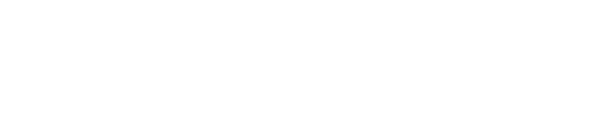

In [34]:
fig = plt.figure(figsize=(6,1.2))
plt.plot(dv.time, dv.flux/100, '-', c='w', lw=1.5)
plt.xlim(0, 20)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.ylim(-13, 7)
plt.tight_layout()
plt.show()

# Save figure
tdir = '/lhome/nicholas/Nextcloud/thesis/image'
fig.savefig(f'{tdir}/lightcurve_gmode.png', bbox_inches='tight', dpi=300, transparent=True)

<IPython.core.display.Javascript object>


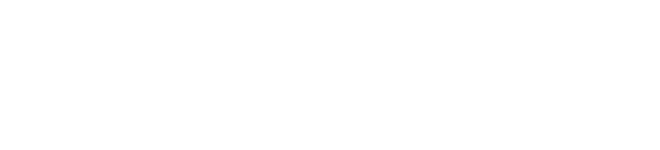

In [54]:
# python varsim.py --star Sun --planet hot-Neptune --seed 9
ds = pd.read_csv(f'{path}/../plot/varsource_sunlike.txt', sep=' ', names=['time', 'dmag'])
time = ds.time / 86400
flux = 10**(-ds.dmag/2.5)

fig = plt.figure(figsize=(6.6,1.5))
plt.plot(time, flux, '-', c='w', lw=0.5)
plt.xlim(3, 60)
plt.xticks([])
plt.yticks([])
plt.axis('off')
# plt.ylim(-13, 7)
plt.tight_layout()
plt.show()

# Save figure
tdir = '/lhome/nicholas/Nextcloud/thesis/image'
fig.savefig(f'{tdir}/lightcurve_sunlike.png', bbox_inches='tight', dpi=300, transparent=True)

### Plots for poster TASC/KASC 2025

<IPython.core.display.Javascript object>


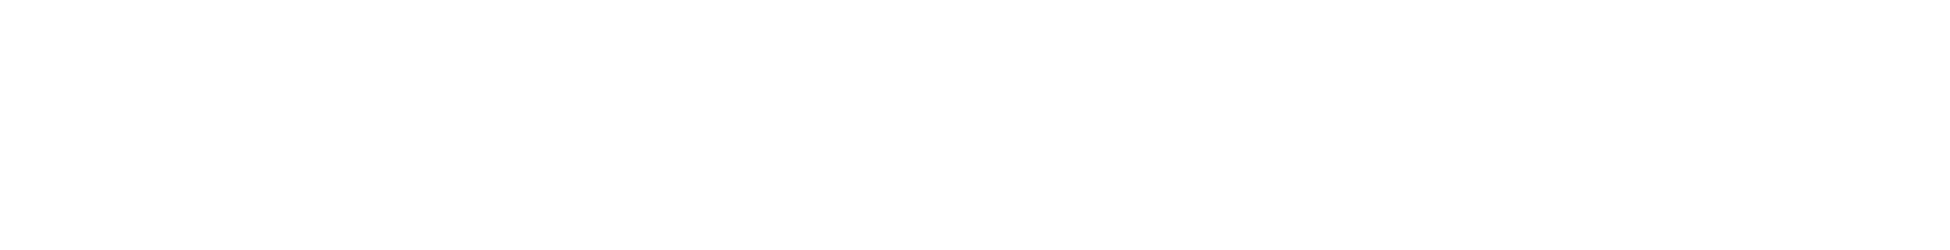

In [21]:
fig = plt.figure(figsize=(19.5,2.5))
plt.plot(dv.time, dv.flux/100, '-', c='w', lw=4)
plt.xlim(0, 20)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.ylim(-13, 7)
plt.tight_layout()
plt.show()

# Save figure
tdir = '/lhome/nicholas/Nextcloud/posters/2025tasckasc'
fig.savefig(f'{tdir}/lightcurve_gmode.png', bbox_inches='tight', dpi=300, transparent=True)

<IPython.core.display.Javascript object>


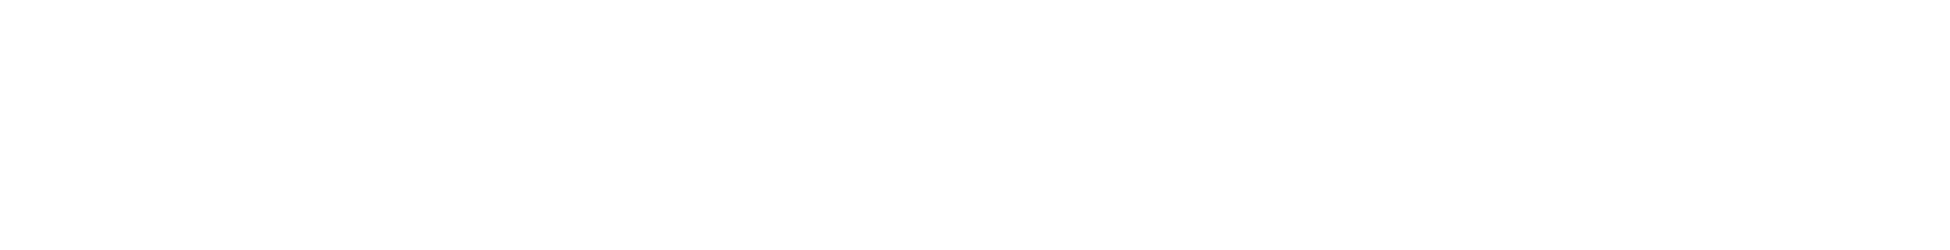

In [19]:
# python varsim.py --star Sun --planet hot-Neptune --seed 9
ds = pd.read_csv(f'{path}/../plot/varsource_sunlike.txt', sep=' ', names=['time', 'dmag'])
time = ds.time / 86400
flux = 10**(-ds.dmag/2.5)

fig = plt.figure(figsize=(19.5,2.5))
plt.plot(time, flux, '-', c='w', lw=2)
plt.xlim(3, 60)
plt.xticks([])
plt.yticks([])
plt.axis('off')
# plt.ylim(-13, 7)
plt.tight_layout()
plt.show()

# Save figure
tdir = '/lhome/nicholas/Nextcloud/posters/2025tasckasc'
fig.savefig(f'{tdir}/lightcurve_sunlike.png', bbox_inches='tight', dpi=300, transparent=True)

---
## Perform analysis
---

In [ ]:
# # Perform general analysis
# da_gdor = mk.fetch_all_modes(path, star='GDOR', batch='affogato')
# dc_gdor = mk.fetch_all_modes(path, star='GDOR', batch='cortado')
# dd_gdor = mk.fetch_all_modes(path, star='GDOR', batch='doppio')
# da_spb  = mk.fetch_all_modes(path, star='SPB',  batch='affogato')
# dc_spb  = mk.fetch_all_modes(path, star='SPB',  batch='cortado')
# dd_spb  = mk.fetch_all_modes(path, star='SPB',  batch='doppio')
# do_spb  = mk.fetch_all_modes(path, star='SPB_high_ampl', batch='finals_affogato', old=True)

# # Save result files
# da_gdor.reset_index(drop=True).to_feather(f'{path}/results_GDOR_affogato.ftr')
# dc_gdor.reset_index(drop=True).to_feather(f'{path}/results_GDOR_cortado.ftr')
# dd_gdor.reset_index(drop=True).to_feather(f'{path}/results_GDOR_doppio.ftr')
# da_spb.reset_index(drop=True).to_feather(f'{path}/results_SPB_affogato.ftr')
# dc_spb.reset_index(drop=True).to_feather(f'{path}/results_SPB_cortado.ftr')
# dd_spb.reset_index(drop=True).to_feather(f'{path}/results_SPB_doppio.ftr')
# do_spb.reset_index(drop=True).to_feather(f'{path}/results_SPB_high_ampl.ftr')

In [7]:
# Load result files
da_gdor = pd.read_feather(f'{path}/results_GDOR_affogato.ftr')
dc_gdor = pd.read_feather(f'{path}/results_GDOR_cortado.ftr')
dd_gdor = pd.read_feather(f'{path}/results_GDOR_doppio.ftr')
da_spb = pd.read_feather(f'{path}/results_SPB_affogato.ftr')
dc_spb = pd.read_feather(f'{path}/results_SPB_cortado.ftr')
dd_spb = pd.read_feather(f'{path}/results_SPB_doppio.ftr')
do_spb = pd.read_feather(f'{path}/results_SPB_high_ampl.ftr')

In [ ]:
# dt_spb, _, _ = mk.fetch_all_modes(path, star='SPB', batch='finals_cortado_withoutTED')

In [8]:
da_gdor

,ID,Pmag,ncam,rOA,SPR,N_bic,N_snr,N_input,A_max,A_limit_bic,A_limit_snr,A_ampl_bic,A_ampl_snr,f_rms_bic,f_rms_snr,A_rms_bic,A_rms_snr
0,540,10.839574,2,18.135953,0.008102,10,4,23,145.774236,12.916031,16.832938,12.916031,18.869723,218.328474,60.899570,4.475229,3.685210
1,2269,11.388591,3,19.528489,0.004438,20,17,45,535.800704,16.544109,20.203965,16.544109,21.749164,148.309143,149.000729,8.440250,9.084231
2,1766,12.864400,3,19.531120,0.000000,2,1,18,138.925733,51.257112,79.036469,53.473875,90.216934,91.992285,96.157304,14.694048,13.887847
3,2318,7.958759,4,19.520870,0.000000,19,18,21,150.050341,2.446459,2.860462,2.629931,4.165813,45.017439,45.869331,2.714709,2.770972
4,51,9.832494,4,18.390289,0.026135,26,25,34,117.306337,5.730058,7.382120,5.986996,7.382120,103.580297,91.384866,2.443667,2.315245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1808,13.883281,24,10.450492,0.003204,5,4,34,62.711111,30.042610,34.674808,30.042610,34.674808,183.378533,134.476414,8.953395,9.875671
3996,2726,13.893029,24,13.348881,0.028256,5,4,16,106.887466,30.537578,35.718727,31.130041,35.718727,65.109824,62.504304,7.507633,8.389290
3997,274,13.896692,24,11.596839,0.022932,6,5,20,91.275964,30.571979,32.869251,30.571979,32.869251,180.211914,197.137997,3.675037,3.943454
3998,747,13.943333,24,12.627131,0.030088,10,10,29,442.087656,31.274047,45.393540,45.393540,45.393540,36.468277,36.468277,6.785150,6.785150


---
## Detection rates
---

### Recovery of mode counts

In [9]:
dx = do_spb
dx0 = dx.sort_values(by=['ncam', 'Pmag']).dropna()

In [10]:
N = np.max([dx.N_input.max(), dx.N_bic.max(), dx.N_snr.max()])

count_input, bin_input = np.histogram(dx.N_input, bins=N, range=(0, N))
count_bic, bin_bic     = np.histogram(dx.N_bic,   bins=N, range=(0, N))
count_snr, bin_snr     = np.histogram(dx.N_snr,   bins=N, range=(0, N))

N_oc_bic = count_bic - count_input
N_oc_snr = count_snr - count_input

<IPython.core.display.Javascript object>


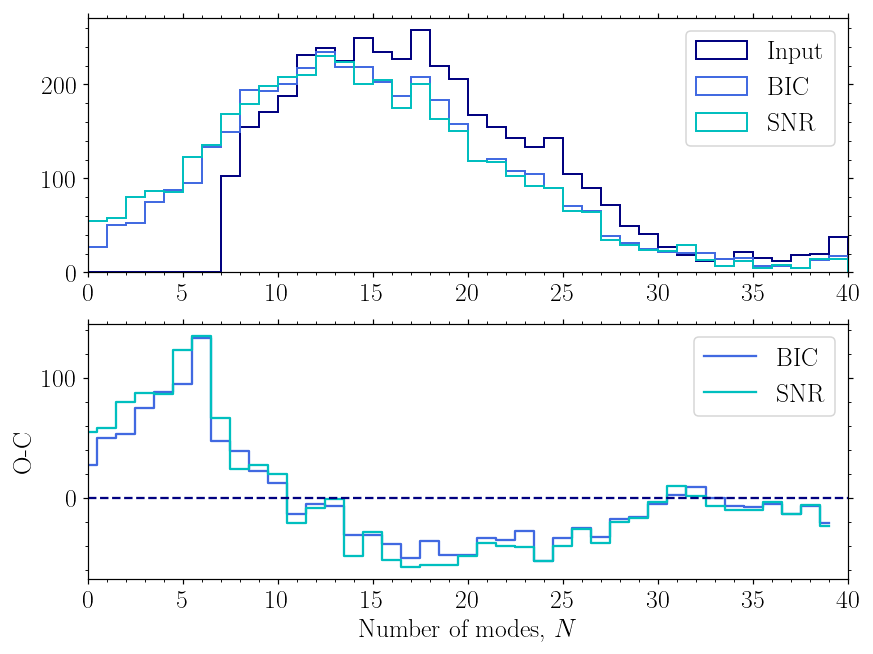

In [11]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(dx.N_input, bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='navy', label='Input')
ax[0].hist(dx.N_bic,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
ax[0].hist(dx.N_snr,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='c', label='SNR')

ax[1].plot(range(0, N), N_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot(range(0, N), N_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
ax[1].plot([0, N], [0, 0], '--', c='navy')
ax[1].set_ylabel('O-C')
ax[1].set_xlabel(r'Number of modes, $N$')

for i in range(panels): 
    ax[i].set_xlim(0, N)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

---
## Detection limit in the Fourier domain
---

In [12]:
# STATISTICS OF DETECTING THE DOMINANT MODE AMPLITUDE
m1_gdor_affogato = da_gdor[da_gdor.N_snr > 0].shape[0] / da_gdor.shape[0] * 100
m1_gdor_cortado  = dc_gdor[dc_gdor.N_snr > 0].shape[0] / dc_gdor.shape[0] * 100
m1_spb_affogato  = da_spb[da_spb.N_snr   > 0].shape[0] / da_spb.shape[0]  * 100
m1_spb_cortado   = dc_spb[dc_spb.N_snr   > 0].shape[0] / dc_spb.shape[0]  * 100

print('Number of stars with the dominant mode detected')
print(f'GDOR, Affogato : {m1_gdor_affogato:.1f} %')
print(f'GDOR, Cortado  : {m1_gdor_cortado:.1f} %')
print(f'SPB , Affogato : {m1_spb_affogato:.1f} %')
print(f'SPB , Cortado  : {m1_spb_cortado:.1f} %')

Number of stars with the dominant mode detected
GDOR, Affogato : 98.9 %
GDOR, Cortado  : 95.8 %
SPB , Affogato : 98.2 %
SPB , Cortado  : 95.3 %


<IPython.core.display.Javascript object>


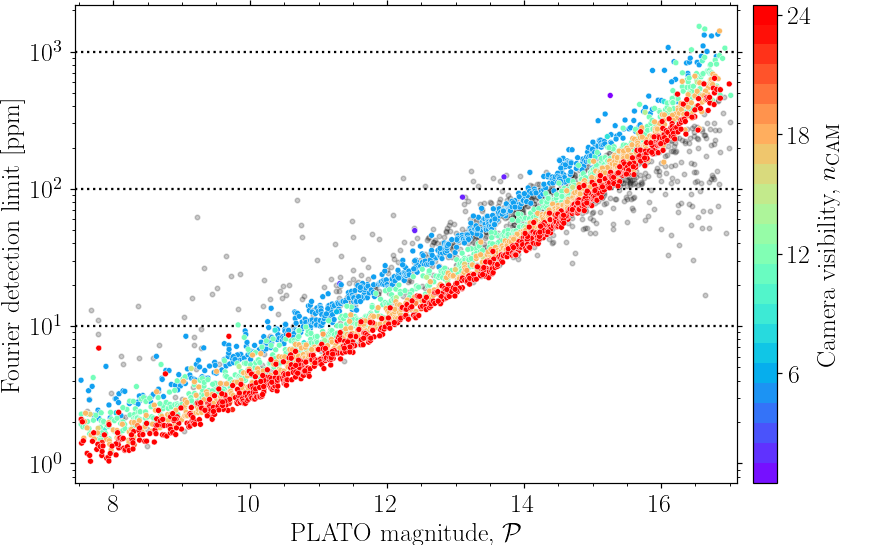

In [16]:
# PLOT FOR PAPER: AMPLITUDE DISTRIBUTION MODEL COMPARISON
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

dx = do_spb.sort_values('ncam', ascending=True)

dy = dx[dx.SPR > 0.06]
ax.plot(dy.Pmag, dy.A_limit_snr, 'ko', ms=3, alpha=0.2, mec=None, zorder=1)

# Plotting
dx = dx[dx.SPR < 0.06]
scat = ax.scatter(dx.Pmag, dx.A_limit_snr, c=dx.ncam, marker='o', edgecolor='w',
                  s=15, lw=0.3, cmap=cmap, zorder=2)

# Colorbar
cbins = np.arange(dx.ncam.min(), dx.ncam.max()+2, 1)
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cbar = plt.colorbar(scat, extend=None, pad=0.02, shrink=1, spacing='proportional',
                    ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')

# Labels
ax.set_ylabel('Fourier detection limit [ppm]')
ax.set_xlabel('PLATO magnitude, $\mathcal{P}$')
cbar.set_label(r'Camera visibility, $n_{\rm CAM}$')

# Settings
ax.axhline(y=1e1, linestyle=':', color='k', zorder=0)
ax.axhline(y=1e2, linestyle=':', color='k', zorder=0)
ax.axhline(y=1e3, linestyle=':', color='k', zorder=0)
ax.set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
ax.set_yscale('log')
plt.tight_layout(pad=-0.01);
# fig.savefig(f'{fdir}/result_limit_fourier_SPB.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


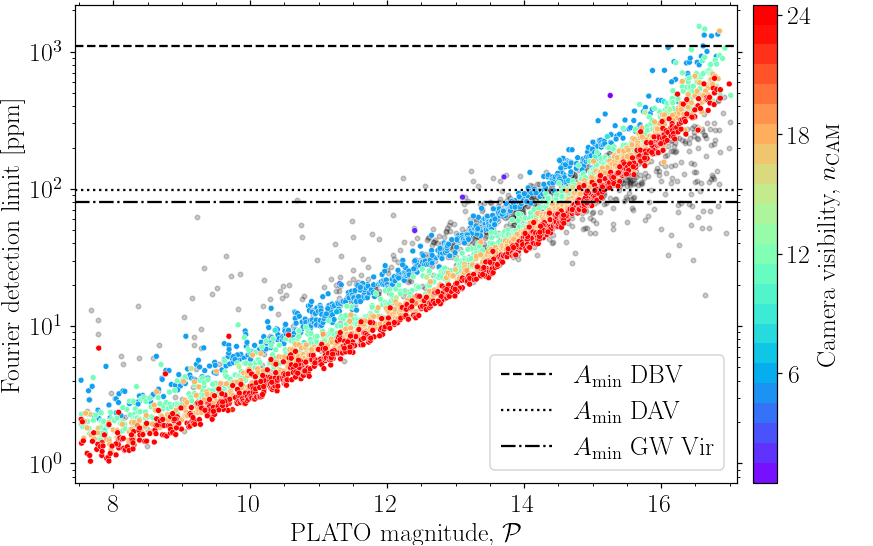

In [38]:
# PLOT FOR PAPER: AMPLITUDE DISTRIBUTION MODEL COMPARISON
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

dx = do_spb.sort_values('ncam', ascending=True)

dy = dx[dx.SPR > 0.06]
ax.plot(dy.Pmag, dy.A_limit_snr, 'ko', ms=3, alpha=0.2, mec=None, zorder=1)

# Plotting
dx = dx[dx.SPR < 0.06]
scat = ax.scatter(dx.Pmag, dx.A_limit_snr, c=dx.ncam, marker='o', edgecolor='w',
                  s=15, lw=0.3, cmap=cmap, zorder=2)
ax.axhline(y=1e3*1.109, linestyle='--', color='k', zorder=2, label=r'$A_{\rm min}$ DBV')
ax.axhline(y=1e3*0.098, linestyle=':',  color='k', zorder=2, label=r'$A_{\rm min}$ DAV')
ax.axhline(y=1e3*0.080, linestyle='-.', color='k', zorder=2, label=r'$A_{\rm min}$ GW Vir')

# Colorbar
cbins = np.arange(dx.ncam.min(), dx.ncam.max()+2, 1)
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cbar = plt.colorbar(scat, extend=None, pad=0.02, shrink=1, spacing='proportional',
                    ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')

# Labels
ax.set_ylabel('Fourier detection limit [ppm]')
ax.set_xlabel('PLATO magnitude, $\mathcal{P}$')
cbar.set_label(r'Camera visibility, $n_{\rm CAM}$')

# Settings
ax.legend(loc='lower right')
ax.set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
ax.set_yscale('log')
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_limit_fourier_WD.png', bbox_inches='tight', dpi=200)

---
## Limiting amplitude detection
---

In [ ]:
# GENERAL PLOT FOR DIAGNOSTIC
dx = dc_gdor

# Setup figure
panels = 7
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Sort data frames
dx0 = dx.sort_values('ncam',    ascending=True)
dx1 = dx.sort_values('rOA',     ascending=True)
dx2 = dx.sort_values('SPR',     ascending=True)
dx3 = dx.sort_values('A_max',   ascending=True)
dx4 = dx.sort_values('N_snr',   ascending=True)
dx5 = dx.sort_values('N_input', ascending=True)
dx6 = dx.sort_values('N_snr',   ascending=False)

c0 = dx0.ncam
c1 = dx1.rOA
c2 = dx2.SPR
c3 = dx3.A_max / 1e3
c4 = dx4.N_snr
c5 = dx5.N_snr / dx5.N_input * 100
c6 = (dx6.N_bic - dx6.N_snr) / dx6.N_snr

l0 = r'$n_{\rm NCAM}$'
l1 = r'$\vartheta_{\rm OA}$'
l2 = 'SPR'
l3 = '$A_1$ [ppt]'
l4 = r'$N_{\rm SNR}$ [Counts]'
l5 = r'$\mathcal{E} = N_{\rm SNR} / N_{\rm Input}$ [\%]'
l6 = r'$N_{\rm BIC} - N_{\rm SNR}$ [Counts]'

# Plotting
for i,dx,c,l in zip(range(panels), [dx0, dx1, dx2, dx3, dx4, dx5, dx6], 
                    [c0, c1, c2, c3, c4, c5, c6], [l0, l1, l2, l3, l4, l5, l6]):
    s = ax[i].scatter(dx.Pmag, dx.A_limit_snr, c=c, marker='o', s=15, lw=0.3, ec='w', cmap=cmap)
    c = plt.colorbar(s, extend='both', pad=0.02, shrink=0.9)
    c.set_label(l)

# Labels
ax[panels-1].set_xlabel('PLATO magnitude, $\mathcal{P}$')

# Settings
for i in range(panels):
    ax[i].set_ylabel('Limiting mode amplitude [ppm]')
    ax[i].set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.1);

In [ ]:
# PLOT FOR PAPER: AMPLITUDE DETECTION LIMIT FOR GDOR SAMPLE
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Plot and colorbar
cbins = np.arange(dx.ncam.min(), dx.ncam.max()+2, 1)
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)

dx = da_gdor.sort_values('ncam', ascending=True)
scat = ax[0].scatter(dx.Pmag, dx.A_ampl_snr, c=dx.ncam,  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, pad=0.02, spacing='proportional', ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')

dx = dc_gdor.sort_values('ncam', ascending=True)
scat = ax[1].scatter(dx.Pmag, dx.A_ampl_snr, c=dx.ncam,  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, pad=0.02, spacing='proportional', ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')
ax[1].axvline(x=9,  linestyle=':', color='k', zorder=0)

# Settings
ax[0].set_title(r'$\gamma$ Dor sample', pad=10)
fig.text(0.08, 0.90, 'Affogato', va='center', rotation='horizontal')
fig.text(0.08, 0.43, 'Cortado', va='center', rotation='horizontal')
fig.text(-0.04, 0.5, 'Limiting amplitude [ppm]', va='center', rotation='vertical')
fig.text(0.92, 0.5, r'Camera visibility, $n_{\rm CAM}$', va='center', rotation='vertical')
ax[1].set_xlabel('PLATO magnitude, $\mathcal{P}$')

for i in range(panels):
#     ax[i].set_ylabel('Detection limit [ppm]')
    ax[i].axhline(y=10, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
    ax[i].set_ylim(1, 1e3)
    ax[i].set_yscale('log')
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_amplitude_limit_GDOR.png', bbox_inches='tight', dpi=200)

In [ ]:
# PLOT FOR PAPER: AMPLITUDE DETECTION LIMIT FOR SPB SAMPLE
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Plot and colorbar
cbins = np.arange(dx.ncam.min(), dx.ncam.max()+2, 1)
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)

dx = da_spb.sort_values('ncam', ascending=True)
scat = ax[0].scatter(dx.Pmag, dx.A_ampl_snr, c=dx.ncam, marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, pad=0.02, spacing='proportional', ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')

dx = dc_spb.sort_values('ncam', ascending=True)
scat = ax[1].scatter(dx.Pmag, dx.A_ampl_snr, c=dx.ncam, marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, pad=0.02, spacing='proportional', ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')

# Labels
ax[0].set_title('SPB sample', pad=10)
fig.text(0.07, 0.90, 'Affogato', va='center', rotation='horizontal')
fig.text(0.07, 0.43, 'Cortado', va='center', rotation='horizontal')
fig.text(-0.04, 0.5, 'Limiting amplitude [ppm]', va='center', rotation='vertical')
fig.text(0.92, 0.5, r'Camera visibility, $n_{\rm NCAM}$', va='center', rotation='vertical')
ax[1].set_xlabel('PLATO magnitude, $\mathcal{P}$')

# Settings
for i in range(panels):
    ax[i].axvline(x=9,  linestyle=':', color='k', zorder=0)
    ax[i].axhline(y=10, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
    ax[i].set_ylim(1, 3e3)
    ax[i].set_yscale('log')
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_amplitude_limit_SPB.png', bbox_inches='tight', dpi=200)

In [ ]:
# PLOT FOR PAPER: AMPLITUDE DISTRIBUTION MODEL COMPARISON
fig, ax = plt.subplots(1, 1, figsize=(8, 3.2))

# Plot and colorbar
cbins = np.arange(dx.ncam.min(), dx.ncam.max()+2, 1)
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)

dx = do_spb.sort_values('ncam', ascending=True)
scat = ax.scatter(dx.Pmag, dx.A_ampl_snr, c=dx.ncam,  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, pad=0.02, spacing='proportional', ticks=[6.5, 12.5, 18.5, 24.5], boundaries=cbins, format='%1i')

ax.axvline(x=12.5, linestyle=':', color='k', zorder=0)
ax.axhline(y=10.0, linestyle=':', color='k', zorder=0)

# Labels
fig.text(0.12, 0.80, 'Affogato', va='center', rotation='horizontal')
ax.set_title(r'SPB sample: high amplitudes', pad=10)
ax.set_ylabel('Limiting amplitude [ppm]')
ax.set_xlabel('PLATO magnitude, $\mathcal{P}$')
cbar.set_label(r'Camera visibility, $n_{\rm NCAM}$')
    
# Settings
ax.set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
ax.set_yscale('log')
ax.set_ylim(1, 5e3)
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_amplitude_limit_SPB_high.png', bbox_inches='tight', dpi=200)

### Detection rates

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_gdor, col='limit', clim=[0, 100],
                                          title=r'$\gamma$ Dor sample',
                                          clab=r'$\mathcal{E}$ (Affogato) [\%]')
fig.savefig(f'{fdir}/result_detection_GDOR_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_gdor, clab=r'$\mathcal{E}$ (Cortado) [\%]', clim=[0, 100])
fig.savefig(f'{fdir}/result_detection_GDOR_cortado.png', bbox_inches='tight', dpi=300);

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        clab=r'$\Delta\mathcal{E}$ (Affogato $-$ Cortado) [\%]')
fig.savefig(f'{fdir}/result_detection_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_spb, title='SPB sample', clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Affogato) [\%]')
fig.savefig(f'{fdir}/result_detection_SPB_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_spb, clim=[0, 100], 
                                          clab=r'$\mathcal{E}$ (Cortado) [\%]')
fig.savefig(f'{fdir}/result_detection_SPB_cortado.png', bbox_inches='tight', dpi=300);

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        clab=r'$\Delta\mathcal{E}$ (Affogato $-$ Cortado) [\%]')
fig.savefig(f'{fdir}/result_detection_SPB_residuals.png', bbox_inches='tight', dpi=300);

### Amplitude precision

In [ ]:
# GENERAL PLOT FOR DIAGNOSTIC
dx = dc_gdor

# Setup figure
panels = 7
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Sort data frames
dx0 = dx.sort_values('ncam',    ascending=True)
dx1 = dx.sort_values('rOA',     ascending=True)
dx2 = dx.sort_values('SPR',     ascending=True)
dx3 = dx.sort_values('A_max',   ascending=True)
dx4 = dx.sort_values('N_snr',   ascending=True)
dx5 = dx.sort_values('N_input', ascending=True)
dx6 = dx.sort_values('N_snr',   ascending=False)

c0 = dx0.ncam
c1 = dx1.rOA
c2 = dx2.SPR
c3 = dx3.A_max / 1e3
c4 = dx4.N_snr
c5 = dx5.N_snr / dx5.N_input * 100
c6 = (dx6.N_bic - dx6.N_snr) / dx6.N_snr

l0 = r'$n_{\rm NCAM}$'
l1 = r'$\vartheta_{\rm OA}$'
l2 = 'SPR'
l3 = '$A_1$ [ppt]'
l4 = r'$N_{\rm SNR}$ [Counts]'
l5 = r'$\mathcal{E} = N_{\rm SNR} / N_{\rm Input}$ [\%]'
l6 = r'$N_{\rm BIC} - N_{\rm SNR}$ [Counts]'

# Plotting
for i,dx,c,l in zip(range(panels), [dx0, dx1, dx2, dx3, dx4, dx5, dx6], 
                    [c0, c1, c2, c3, c4, c5, c6], [l0, l1, l2, l3, l4, l5, l6]):
    s = ax[i].scatter(dx.Pmag, dx.A_rms_snr, c=c, marker='o', s=15, lw=0.3, ec='w', cmap=cmap)
    c = plt.colorbar(s, extend='both', pad=0.02, shrink=0.9)
    c.set_label(l)

# Labels
ax[panels-1].set_xlabel('PLATO magnitude, $\mathcal{P}$')

# Settings
for i in range(panels):
    ax[i].set_ylabel('Amplitude precision [ppm]')
    ax[i].set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.4);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_gdor, col='A_rms_snr', title=r'$\gamma$ Dor sample', 
                                          clim=[0, 35], cext='max',
                                          clab=r'$\langle \delta A_{\rm rms}\rangle$ (Affogato) [ppm]')
fig.savefig(f'{fdir}/result_amplitude_GDOR_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_gdor, col='A_rms_snr', clim=[0, 35], cext='max',
                                          clab=r'$\langle\delta A_{\rm rms}\rangle$ (Cortado) [ppm]')
fig.savefig(f'{fdir}/result_amplitude_GDOR_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='A_rms_snr', clim=[0, 55], cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{A}$ [\%]')
fig.savefig(f'{fdir}/result_amplitude_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_spb, col='A_rms_snr', title='SPB sample', 
                                          clim=[0, 300], cext='max',
                                          clab=r'$\langle \delta A_{\rm rms}\rangle$ (Affogato) [ppm]')
fig.savefig(f'{fdir}/result_amplitude_SPB_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_spb, col='A_rms_snr', clim=[0, 300], cext='max',
                                          clab=r'$\langle\delta A_{\rm rms}\rangle$ (Cortado) [ppm]')
fig.savefig(f'{fdir}/result_amplitude_SPB_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='A_rms_snr', cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{A}$ [\%]')
fig.savefig(f'{fdir}/result_amplitude_SPB_residuals.png', bbox_inches='tight', dpi=300);

### Frequency precision

In [ ]:
# GENERAL PLOT FOR DIAGNOSTIC
dx = dc_gdor

# Setup figure
panels = 7
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Sort data frames
dx0 = dx.sort_values('ncam',    ascending=True)
dx1 = dx.sort_values('rOA',     ascending=True)
dx2 = dx.sort_values('SPR',     ascending=True)
dx3 = dx.sort_values('A_max',   ascending=True)
dx4 = dx.sort_values('N_snr',   ascending=True)
dx5 = dx.sort_values('N_input', ascending=True)
dx6 = dx.sort_values('N_snr',   ascending=False)

c0 = dx0.ncam
c1 = dx1.rOA
c2 = dx2.SPR
c3 = dx3.A_max / 1e3
c4 = dx4.N_snr
c5 = dx5.N_snr / dx5.N_input * 100
c6 = (dx6.N_bic - dx6.N_snr) / dx6.N_snr

l0 = r'$n_{\rm NCAM}$'
l1 = r'$\vartheta_{\rm OA}$'
l2 = 'SPR'
l3 = '$A_1$ [ppt]'
l4 = r'$N_{\rm SNR}$ [Counts]'
l5 = r'$\mathcal{E} = N_{\rm SNR} / N_{\rm Input}$ [\%]'
l6 = r'$N_{\rm BIC} - N_{\rm SNR}$ [Counts]'

# Plotting
for i,dx,c,l in zip(range(panels), [dx0, dx1, dx2, dx3, dx4, dx5, dx6], 
                    [c0, c1, c2, c3, c4, c5, c6], [l0, l1, l2, l3, l4, l5, l6]):
    s = ax[i].scatter(dx.Pmag, dx.f_rms_snr, c=c, marker='o', s=15, lw=0.3, ec='w', cmap=cmap)
    c = plt.colorbar(s, extend='both', pad=0.02, shrink=0.9)
    c.set_label(l)

# Labels
ax[panels-1].set_xlabel('PLATO magnitude, $\mathcal{P}$')

# Settings
for i in range(panels):
    ax[i].set_ylabel('Detection limit [ppm]')
    ax[i].set_xlim(pt.getAxesMinMax(dx.Pmag, percentage=1))
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.1);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_gdor, col='f_rms_snr', clim=[40, 95], cext='both', 
                                          clab=r'$\langle\delta \nu_{\rm rms}\rangle$ (Affogato) [$10^{-4}$ d$^{-1}$]', 
                                          title=r'$\gamma$ Dor sample')
fig.savefig(f'{fdir}/result_frequency_GDOR_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_gdor, col='f_rms_snr', clim=[40, 95], cext='both',
                                          clab=r'$\langle\delta \nu_{\rm rms}\rangle$ (Cortado) [$10^{-4}$ d$^{-1}$]')
fig.savefig(f'{fdir}/result_frequency_GDOR_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='f_rms_snr', cext='both', cmap='coolwarm',
                                     clab=r'Fractional residuals, $\Psi_{\nu}$ [\%]')
fig.savefig(f'{fdir}/result_frequency_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_spb, col='f_rms_snr', clim=[25, 120], cext='both',
                                          clab=r'$\langle\delta \nu_{\rm rms}\rangle$ (Affogato) [$10^{-4}$ d$^{-1}$]', 
                                          title='SPB sample')
fig.savefig(f'{fdir}/result_frequency_SPB_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_spb, col='f_rms_snr', clim=[25, 120], cext='both',
                                          clab=r'$\langle\delta \nu_{\rm rms}\rangle$ (Cortado) [$10^{-4}$ d$^{-1}$]')
fig.savefig(f'{fdir}/result_frequency_SPB_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='f_rms_snr', cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{\nu}$ [\%]')
fig.savefig(f'{fdir}/result_frequency_SPB_residuals.png', bbox_inches='tight', dpi=300);

---
## Impact of stellar contamination
---

In [ ]:
da0_gdor = da_gdor[da_gdor.SPR == 0].sort_values(by=['ID'])
da1_gdor = da_gdor[da_gdor.SPR != 0].sort_values(by=['ID'])
dc1_gdor = dc_gdor[dc_gdor.SPR != 0].sort_values(by=['ID'])
print(f'Number of GDOR stars contaminated: {da1_gdor.shape[0]}')

da0_spb = da_spb[da_spb.SPR == 0].sort_values(by=['ID'])
da1_spb = da_spb[da_spb.SPR != 0].sort_values(by=['ID'])
dc1_spb = dc_spb[dc_spb.SPR != 0].sort_values(by=['ID'])
print(f'Number of SPB  stars contaminated: {da1_spb.shape[0]}')

In [ ]:
# Save a parameterisation file for the VSC
np.savetxt(f'{path}/../../slurm/cluster_varlist_GDOR.txt', 
           da_gdor.ID.to_numpy(), fmt=['%i'], header='ID')
np.savetxt(f'{path}/../../slurm/cluster_varlist_SPB.txt', 
           da_spb.ID.to_numpy(), fmt=['%i'], header='ID')

### Simple case: non-variable contaminants

In [ ]:
# PLOT FOR PAPER: IMPACT OF CONTAMINATION FROM QUIET STARS ON AMPLITUDE PRECISION
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Plots
dx = da_gdor.sort_values('A_max', ascending=True)
col = dx.A_max/1e3
scat = ax[0].scatter(dx.SPR, dx.A_rms_snr, c=col, marker='o', s=15, lw=0.3, ec='w', cmap=cmap, vmin=0, vmax=3.1)
cbar = plt.colorbar(scat, extend='max', pad=0.02, ticks=[0, 1, 2, 3])

dx = dc_gdor.sort_values('A_max', ascending=True)
col = dx.A_max/1e3
scat = ax[1].scatter(dx.SPR, dx.A_rms_snr, c=col, marker='o', s=15, lw=0.3, ec='w', cmap=cmap)
cbar = plt.colorbar(scat, extend='both', pad=0.02)

# Labels
ax[0].set_title(r'$\gamma$ Dor sample', pad=10)
fig.text(0.12, 0.90, 'Affogato', va='center', rotation='horizontal')
fig.text(0.12, 0.44, 'Cortado',  va='center', rotation='horizontal')
fig.text(0.92, 0.5, r'Dominant mode amplitude, $A_1$ [ppt]', va='center', rotation='vertical')
fig.text(-0.04, 0.5, r'Amplitude presicion, $\langle\delta A_{\rm rms}\rangle$ [ppm]', va='center', rotation='vertical')
ax[1].set_xlabel('SPR')

# Settings
for i in range(panels):
    ax[i].axvline(x=0.06, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(1.2e-5, 1)
    ax[i].set_ylim(1e-1, 1e3)
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_contamination_GDOR_Arms-SPR-A1.png', bbox_inches='tight', dpi=200)

In [ ]:
# PLOT FOR PAPER: IMPACT OF CONTAMINATION FROM QUIET STARS ON AMPLITUDE PRECISION
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))
col = 'Pmag'

# Plots
dx = da_gdor.sort_values(col, ascending=True)
scat = ax[0].scatter(dx.SPR, dx.A_rms_snr, c=dx[col], marker='o', s=15, lw=0.3, ec='w', cmap=cmap, clim=[7.5, 14])
cbar = plt.colorbar(scat, extend=None, pad=0.02, shrink=0.95, ticks=[8, 10, 12, 14])

dx = dc_gdor.sort_values(col, ascending=True)
scat = ax[1].scatter(dx.SPR, dx.A_rms_snr, c=dx[col], marker='o', s=15, lw=0.3, ec='w', cmap=cmap, clim=[7.5, 14])
cbar = plt.colorbar(scat, extend=None, pad=0.02, shrink=0.95, ticks=[8, 10, 12, 14])

# Labels
ax[0].set_title('$\gamma$ Dor sample', pad=10)
fig.text(0.12, 0.90, 'Affogato', va='center', rotation='horizontal')
fig.text(0.12, 0.44, 'Cortado',  va='center', rotation='horizontal')
fig.text(0.93, 0.50, r'PLATO magnitude, $\mathcal{P}$', va='center', rotation='vertical')
fig.text(-0.04, 0.5, r'Amplitude presicion, $\langle\delta A_{\rm rms}\rangle$ [ppm]', va='center', rotation='vertical')
ax[1].set_xlabel('SPR')

# Settings
for i in range(panels):
    ax[i].axvline(x=0.06, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(1.2e-5, 1)
    ax[i].set_ylim(1e-1, 3e3)
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_contamination_GDOR_Arms-SPR-P.png', bbox_inches='tight', dpi=200)

In [ ]:
# PLOT FOR PAPER: IMPACT OF CONTAMINATION FROM QUIET STARS ON AMPLITUDE PRECISION
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Plots
dx = da_spb.sort_values('A_max', ascending=True)
col = dx.A_max/1e3
scat = ax[0].scatter(dx.SPR, dx.A_rms_snr, c=col, marker='o', s=15, lw=0.3, ec='w', cmap=cmap)
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=0.95)

dx = dc_spb.sort_values('A_max', ascending=True)
col = dx.A_max/1e3
scat = ax[1].scatter(dx.SPR, dx.A_rms_snr, c=col, marker='o', s=15, lw=0.3, ec='w', cmap=cmap)
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=0.95)

# Labels
ax[0].set_title('SPB sample', pad=10)
fig.text(0.12, 0.90, 'Affogato', va='center', rotation='horizontal')
fig.text(0.12, 0.44, 'Cortado',  va='center', rotation='horizontal')
fig.text(0.92, 0.5, r'Dominant mode amplitude, $A_1$ [ppt]', va='center', rotation='vertical')
fig.text(-0.04, 0.5, r'Amplitude presicion, $\langle\delta A_{\rm rms}\rangle$ [ppm]', va='center', rotation='vertical')
ax[1].set_xlabel('SPR')

# Settings
for i in range(panels):
    ax[i].axvline(x=0.06, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(1.2e-5, 1)
    ax[i].set_ylim(1e-1, 3e3)
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
plt.tight_layout(pad=-0.01);
fig.savefig(f'{fdir}/result_contamination_SPB_Arms-SPR-A1.png', bbox_inches='tight', dpi=200)

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_gdor, col='limit', clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Affogato-all) [\%]')

fig, ax, ddc = mk.plot_percentage_heatmap(da1_gdor, clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Affogato-con) [\%]')

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        title=r'$\gamma$ Dor sample',
                                        clab=r'$\Delta\mathcal{E}$ Affogato (All $-$ Cont.) [\%]')
fig.savefig(f'{fdir}/result_contamination_GDOR_residuals_none.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(dc_gdor, col='limit', clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Cortado all) [\%]')

fig, ax, ddc = mk.plot_percentage_heatmap(dc1_gdor, clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Cortado cont.) [\%]')

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        clab=r'$\Delta\mathcal{E}$, Cortado (All $-$ Cont.) [\%]')
fig.savefig(f'{fdir}/result_contamination_GDOR_residuals_cortado_none.png', bbox_inches='tight', dpi=300);

---

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_spb, col='limit', clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Affogato-all) [\%]')

fig, ax, ddc = mk.plot_percentage_heatmap(da1_spb, clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Affogato-con) [\%]')

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        title='SPB sample',
                                        clab=r'$\Delta\mathcal{E}$ Affogato (All $-$ Cont.) [\%]')
fig.savefig(f'{fdir}/result_contamination_SPB_residuals_none.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(dc_spb, col='limit', clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Cortado all) [\%]')

fig, ax, ddc = mk.plot_percentage_heatmap(dc1_spb, clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Cortado cont.) [\%]')

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        clab=r'$\Delta\mathcal{E}$, Cortado (All $-$ Cont.) [\%]')
fig.savefig(f'{fdir}/result_contamination_SPB_residuals_cortado_none.png', bbox_inches='tight', dpi=300);

### Varible contaminants

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da1_gdor, col='limit', clim=[0, 100],
                                          title=r'$\gamma$ Dor sample',
                                          clab=r'$\mathcal{E}$ (Affogato) [\%]')

fig, ax, ddc = mk.plot_percentage_heatmap(dd_gdor, clim=[0, 100], 
                                          clab=r'$\mathcal{E}$ (Doppio) [\%]')

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        clab=r'$\Delta\mathcal{E}$ (Affogato $-$ Doppio) [\%]')
fig.savefig(f'{fdir}/result_contamination_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da1_spb, col='limit', clim=[0, 100],
                                          clab=r'$\mathcal{E}$ (Affogato) [\%]')

fig, ax, ddc = mk.plot_percentage_heatmap(dd_spb, clim=[0, 100], 
                                          clab=r'$\mathcal{E}$ (Doppio) [\%]')

fig, ax, _ = mk.plot_percentage_heatmap(dda-ddc, clim=[0, 30], cext='both', cmap='coolwarm',
                                        clab=r'$\Delta\mathcal{E}$ (Affogato $-$ Doppio) [\%]')
fig.savefig(f'{fdir}/result_contamination_SPB_residuals.png', bbox_inches='tight', dpi=300);

---

In [ ]:
# Impact of contamination from "quiet" stars
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

# Plots
col = 'A_max'
dx = da_gdor.sort_values(col, ascending=True)
scat = ax[0].scatter(dx.SPR, dx.f_rms_snr, c=dx[col], marker='o', s=15, lw=0.3, ec='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=0.95)
dx = dc_gdor.sort_values(col, ascending=True)
scat = ax[1].scatter(dx.SPR, dx.f_rms_snr, c=dx[col], marker='o', s=15, lw=0.3, ec='w', cmap=cmap, zorder=1)
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=0.95)

# Labels
ax[0].set_title(r'$\gamma$ Dor sample', pad=10)
fig.text(0.12, 0.90, 'Affogato', va='center', rotation='horizontal')
fig.text(0.12, 0.44, 'Cortado',  va='center', rotation='horizontal')
fig.text(0.92, 0.5, r'Dominant mode amplitude, $A_1$ [ppt]', va='center', rotation='vertical')
fig.text(-0.04, 0.5, 'Amplitude presicion [ppm]', va='center', rotation='vertical')
ax[1].set_xlabel('SPR')

# Settings
for i in range(panels):
    ax[i].axvline(x=0.06, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(1.2e-5, 1)
    ax[i].set_ylim(1e-1, 1e3)
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
plt.tight_layout(pad=-0.01);
# fig.savefig(f'{fdir}/result_contamination_GDOR_Arms-SPR-NCAM.png', bbox_inches='tight', dpi=200)

---
## Choice of prewhitening stopping criterion
---

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_gdor, col='N_bic-N_snr', clim=[0, 3], cext='both',
                                          clab=r'$N_{\rm BIC}-N_{\rm SNR}$ (Affogato) [Count]', 
                                          title='$\gamma$ Dor sample', )
fig.savefig(f'{fdir}/result_nmodes_GDOR_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_gdor, col='N_bic-N_snr', clim=[0, 3], cext='both',
                                          clab=r'$N_{\rm BIC}-N_{\rm SNR}$ (Cortado) [Count]')
fig.savefig(f'{fdir}/result_nmodes_GDOR_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='phi', clim=[0, 90], cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{N}$ [\%]')
fig.savefig(f'{fdir}/result_nmodes_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_spb, col='N_bic-N_snr', clim=[0, 3], cext='both',
                                          clab=r'$N_{\rm BIC}-N_{\rm SNR}$ (Cortado) [Count]', 
                                          title='SPB sample')
fig.savefig(f'{fdir}/result_nmodes_SPB_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_spb, col='N_bic-N_snr', clim=[0, 3], cext='both',
                                          clab=r'$N_{\rm BIC}-N_{\rm SNR}$ (Cortado) [Count]')
fig.savefig(f'{fdir}/result_nmodes_SPB_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='phi', clim=[0, 90], cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{N}$ [\%]')
fig.savefig(f'{fdir}/result_nmodes_SPB_residuals.png', bbox_inches='tight', dpi=300);

### Relative change in N

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_gdor, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
                                          title='$\gamma$ Dor sample', clab=r'$\Delta N$ (Affogato) [\%]')
fig.savefig(f'{fdir}/result_nmodes_GDOR_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_gdor, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
                                          clab=r'$\Delta N$ (Cortado) [\%]')
fig.savefig(f'{fdir}/result_nmodes_GDOR_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='phi', clim=[0, 90], cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{N}$ [\%]')
fig.savefig(f'{fdir}/result_nmodes_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
# dax_gdor = da_gdor[da_gdor.SPR == 0]
# dcx_gdor = dc_gdor[dc_gdor.SPR == 0]

# fig, ax, dda = mk.plot_percentage_heatmap(dax_gdor, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
#                                           title='$\gamma$ Dor sample', clab=r'$\Delta N$ (Affogato) [\%]')
# # fig.savefig(f'{fdir}/result_nmodes_GDOR_affogato.png', bbox_inches='tight', dpi=300);

# fig, ax, ddc = mk.plot_percentage_heatmap(dcx_gdor, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
#                                           clab=r'$\Delta N$ (Cortado) [\%]')
# # fig.savefig(f'{fdir}/result_nmodes_GDOR_cortado.png', bbox_inches='tight', dpi=300);

# phi = (ddc - dda) / ddc * 100
# fig, ax, _ = mk.plot_percentage_heatmap(phi, col='phi', clim=[0, 90], cext='both',
#                                         clab=r'Fractional residuals, $\Psi_{N}$ [\%]')
# # fig.savefig(f'{fdir}/result_nmodes_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
# dax_gdor = da_gdor[da_gdor.SPR != 0]
# dcx_gdor = dc_gdor[dc_gdor.SPR != 0]

# fig, ax, dda = mk.plot_percentage_heatmap(dax_gdor, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
#                                           title='$\gamma$ Dor sample', clab=r'$\Delta N$ (Affogato) [\%]')
# # fig.savefig(f'{fdir}/result_nmodes_GDOR_affogato.png', bbox_inches='tight', dpi=300);

# fig, ax, ddc = mk.plot_percentage_heatmap(dcx_gdor, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
#                                           clab=r'$\Delta N$ (Cortado) [\%]')
# # fig.savefig(f'{fdir}/result_nmodes_GDOR_cortado.png', bbox_inches='tight', dpi=300);

# phi = (ddc - dda) / ddc * 100
# fig, ax, _ = mk.plot_percentage_heatmap(phi, col='phi', clim=[0, 90], cext='both',
#                                         clab=r'Fractional residuals, $\Psi_{N}$ [\%]')
# # fig.savefig(f'{fdir}/result_nmodes_GDOR_residuals.png', bbox_inches='tight', dpi=300);

In [ ]:
fig, ax, dda = mk.plot_percentage_heatmap(da_spb, col='N_bic-N_snr/N_input', title='SPB sample', clim=[0, 12.5], cext='both',
                                          clab=r'$\Delta N$ (Affogato) [\%]')
fig.savefig(f'{fdir}/result_nmodes_SPB_affogato.png', bbox_inches='tight', dpi=300);

fig, ax, ddc = mk.plot_percentage_heatmap(dc_spb, col='N_bic-N_snr/N_input', clim=[0, 12.5], cext='both',
                                          clab=r'$\Delta N$ (Cortado) [\%]')
fig.savefig(f'{fdir}/result_nmodes_SPB_cortado.png', bbox_inches='tight', dpi=300);

phi = (ddc - dda) / ddc * 100
fig, ax, _ = mk.plot_percentage_heatmap(phi, col='phi', clim=[0, 90], cext='both', cmap='coolwarm',
                                        clab=r'Fractional residuals, $\Psi_{N}$ [\%]')
fig.savefig(f'{fdir}/result_nmodes_SPB_residuals.png', bbox_inches='tight', dpi=300);